Data Preparation and Preprocessing

In [ ]:
import pandas as pd                 # For data manipulation and analysis
from sklearn.impute import SimpleImputer # For handling missing values
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder # For scaling and encoding
from sklearn.model_selection import train_test_split # For spliting data for training/testing
import numpy as np                  # For numerical operations
import matplotlib.pyplot as plt     # For basic plotting (e.g., outlier detection)
import seaborn as sns               # For enhanced visualizations (e.g., outlier detection)

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:

plt.rcParams['font.family'] = 'DejaVu Sans'  # Default and safe Font Type


In [ ]:
file_path = "/content/malicious_phishMain.csv" # Saving File Path in a File

try:
    df = pd.read_csv(file_path) #Save and Read the Dataset
    print(f"Dataset '{file_path}' loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded or the path is correct.")

Dataset '/content/malicious_phishMain.csv' loaded successfully.


In [ ]:
#Dataset Information and Context
print("\n--- First 10 rows of the dataset ---")
print(df.head(10))#Display the first 10 rows

print("\n--- Dataset Information (Columns, Non-Null Counts, Dtypes) ---")
print(df.info())

print("\n--- Basic Statistical Summary of Numerical Columns ---")
print(df.describe())

print("\n--- Check unique values for potential categorical columns ---")
#Unique Values in URL and Type columns
if 'url' in df.columns:
    print(f"\nUnique values in 'url' column: {df['url'].unique()}")
    print(f"Value counts for 'url' column:\n{df['url'].value_counts()}")
if 'type' in df.columns:
    print(f"\nNumber of unique types: {df['type'].nunique()}")
    print(f"name of Unique types: {df['type'].unique()}")



--- First 10 rows of the dataset ---
                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement
5  http://buzzfil.net/m/show-art/ils-etaient-loin...      benign
6      espn.go.com/nba/player/_/id/3457/brandon-rush      benign
7     yourbittorrent.com/?q=anthony-hamilton-soulife      benign
8       http://www.pashminaonline.com/pure-pashminas  defacement
9      allmusic.com/album/crazy-from-the-heat-r16990      benign

--- Dataset Information (Columns, Non-Null Counts, Dtypes) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 

In [ ]:
#Handling Missing Values In the Dataset
print("\n--- Missing Values Before Handling ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) # Display only columns with missing values

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print(f"\nTotal missing values across all columns: {missing_values.sum()}")
    print("Columns with missing values and their counts are listed above.")


--- Missing Values Before Handling ---
Series([], dtype: int64)
No missing values found in the dataset.


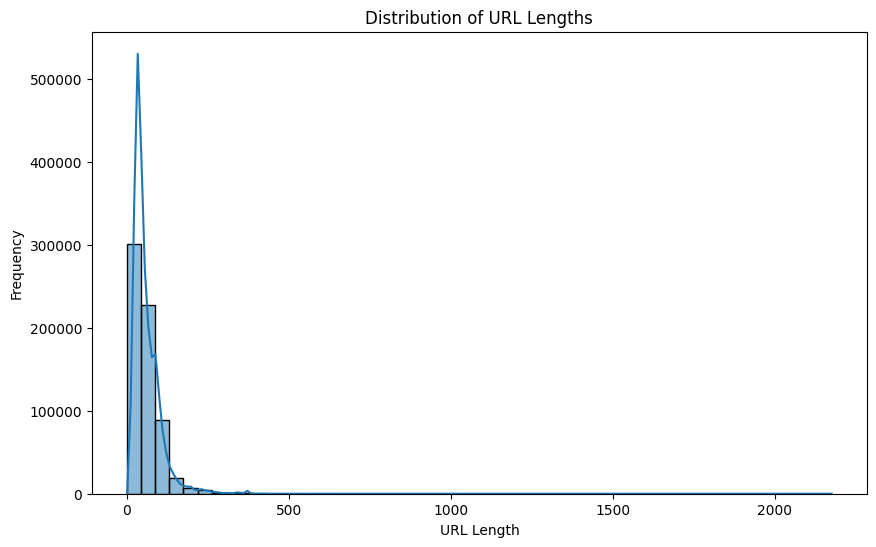

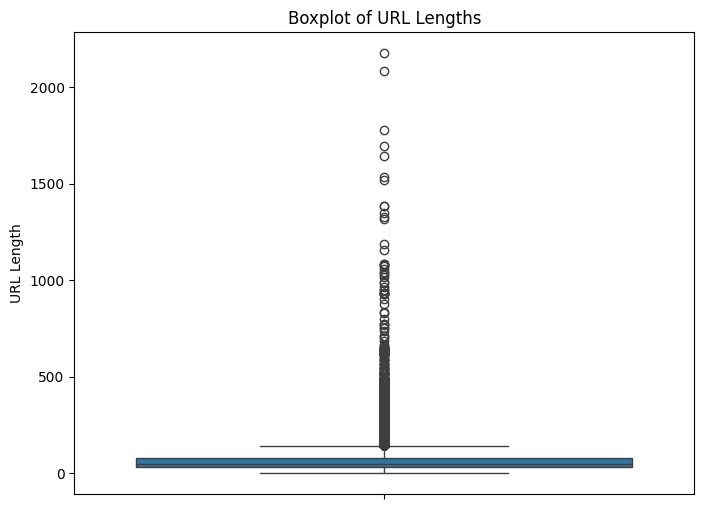


Threshold for unusually long URLs: 235.0

Number of potentially long URLs: 6413


In [ ]:
#Handling Potential "Outliers" in URL Length (as a proxy)

# Analyze the length of the 'url' column
df['url_length'] = df['url'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df['url_length'], bins=50, kde=True)
plt.title('Distribution of URL Lengths')
plt.xlabel('URL Length')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['url_length'])
plt.title('Boxplot of URL Lengths')
plt.ylabel('URL Length')
plt.show()

# Define a threshold for unusually long URLs
long_url_threshold = df['url_length'].quantile(0.99) # Consider URLs in the top 1% length

print(f"\nThreshold for unusually long URLs: {long_url_threshold}")

# Flag potentially long URLs
df['is_long_url'] = df['url_length'] > long_url_threshold
print("\nNumber of potentially long URLs:", df['is_long_url'].sum())


# Drop the temporary 'url_length' and 'is_long_url'
df = df.drop(['url_length', 'is_long_url'], axis=1, errors='ignore')

In [ ]:
#Handling Inconsistencies
print("\n--- Handling Inconsistencies ---")

# Re-identify categorical columns after potential imputation
categorical_cols_for_inconsistency = df.select_dtypes(include='object').columns.tolist()

#'type' column: Standardize by stripping whitespace and converting to lowercase
if 'type' in categorical_cols_for_inconsistency:
    print(f"\nOriginal unique 'type' values: {df['type'].unique()}")
    df['type'] = df['type'].astype(str).str.strip().str.lower()
    print(f"Cleaned unique 'type' values: {df['type'].unique()}")
    print("Applied lowercasing and stripping to 'type' column for consistency.")

#'url' column: Basic URL standardization
if 'url' in categorical_cols_for_inconsistency:
    print(f"\nOriginal unique 'url' values (sample): {df['url'].unique()[:5]}...")
    # Remove common prefixes, trailing slashes, and convert to lowercase
    df['url'] = df['url'].astype(str).str.replace('http://', '', regex=False)
    df['url'] = df['url'].str.replace('https://', '', regex=False)
    df['url'] = df['url'].str.replace('www.', '', regex=False) # Use regex=False for exact string match
    df['url'] = df['url'].str.rstrip('/') # Remove trailing slash
    df['url'] = df['url'].str.lower()
    print(f"Cleaned unique 'url' values (sample): {df['url'].unique()[:5]}...")
    print("Applied basic cleaning (http/https/www removal, trailing slash, lowercase) to 'url' column.")


--- Handling Inconsistencies ---

Original unique 'type' values: ['phishing' 'benign' 'defacement' 'malware']
Cleaned unique 'type' values: ['phishing' 'benign' 'defacement' 'malware']
Applied lowercasing and stripping to 'type' column for consistency.

Original unique 'url' values (sample): ['br-icloud.com.br' 'mp3raid.com/music/krizz_kaliko.html'
 'bopsecrets.org/rexroth/cr/1.htm'
 'http://www.garage-pirenne.be/index.php?option=com_content&view=article&id=70&vsig70_0=15'
 'http://adventure-nicaragua.net/index.php?option=com_mailto&tmpl=component&link=aHR0cDovL2FkdmVudHVyZS1uaWNhcmFndWEubmV0L2luZGV4LnBocD9vcHRpb249Y29tX2NvbnRlbnQmdmlldz1hcnRpY2xlJmlkPTQ3OmFib3V0JmNhdGlkPTM2OmRlbW8tYXJ0aWNsZXMmSXRlbWlkPTU0']...
Cleaned unique 'url' values (sample): ['br-icloud.com.br' 'mp3raid.com/music/krizz_kaliko.html'
 'bopsecrets.org/rexroth/cr/1.htm'
 'garage-pirenne.be/index.php?option=com_content&view=article&id=70&vsig70_0=15'
 'adventure-nicaragua.net/index.php?option=com_mailto&tmpl=compone

In [ ]:
# Identify numerical columns for scaling
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

# Check if numerical_columns is empty
if not numerical_columns:
    print("Warning: No numerical columns found for scaling. Check your data types.")
else:
    # Apply StandardScaler instead of MinMaxScaler
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
    print("Applied StandardScaler to numerical columns.")


In [ ]:
#Encoding Categorical Variables
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])
df['type_binary'] = df['type_encoded'].apply(lambda x: 0 if x == 0 else 1)
df = df.drop(columns=['type'])
df = df.drop(columns=['type_encoded'])
df['url_encoded'] = le.fit_transform(df['url'])
df = df.drop(columns=['url'])
print(df.head(10))
print()
print(df.info())

   type_binary  url_encoded
0            1        99718
1            0       380335
2            0        98220
3            1       245185
4            1        32122
5            0       106134
6            0       201651
7            0       618385
8            1       427327
9            0        39518

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   type_binary  651191 non-null  int64
 1   url_encoded  651191 non-null  int64
dtypes: int64(2)
memory usage: 9.9 MB
None


In [ ]:
#Saving the preprocessed dataset
output_file_name = "MaliciousProcessedData.csv"
df.to_csv(output_file_name, index=False) # index=False prevents writing the DataFrame index as a column

print(f"\nProcessed dataset saved as: {output_file_name}")
print("\n--- Data Preprocessing Complete ---")


Processed dataset saved as: MaliciousProcessedData.csv

--- Data Preprocessing Complete ---


Model Training

In [ ]:
# STEP 1: Separate Features and Target
X = df.drop(columns=['type_binary'])
y = df['type_binary']



# STEP 2: Train-Test Split (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 520952, Testing samples: 130239


In [ ]:
# STEP 3: Apply SMOTEENN to balance training data
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(random_state=42)
# The fit_resample method expects only X_train and y_train as arguments
X_train_bal, y_train_bal = smote_enn.fit_resample(X_train, y_train)

print("Applied SMOTEENN. New class distribution:")
print(pd.Series(y_train_bal).value_counts())

Applied SMOTEENN. New class distribution:
type_binary
1    275202
0    259722
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight # Import the function

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_bal),
    y=y_train_bal
)
class_weight_dict = {cls: weight for cls, weight in zip(np.unique(y_train_bal), class_weights)}

In [ ]:
from sklearn.ensemble import RandomForestClassifier #Importing Random Forest Model

# Initialize and train
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_bal, y_train_bal)
print("Random Forest trained successfully.")


Random Forest trained successfully.


In [ ]:
from xgboost import XGBClassifier #Importing XGBoost Model

# Initialize and train
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_bal, y_train_bal)
print("XGBoost trained successfully.")


XGBoost trained successfully.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier #Importing KNNeighbors Model

# Initialize and train
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_bal, y_train_bal)
print("KNN trained successfully.")


KNN trained successfully.


In [ ]:
from sklearn.neural_network import MLPClassifier #Importing Neural Network Model

# Initialize and train
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    early_stopping=True,    # Stop when validation score stops improving
    max_iter=1000,
    random_state=42
)
mlp.fit(X_train_bal, y_train_bal)

print("Neural Network trained successfully.")

Neural Network trained successfully.


In [ ]:
from sklearn.naive_bayes import GaussianNB #Importing Naive Bayes Model

# Initialize and train
nb = GaussianNB()
nb.fit(X_train_bal, y_train_bal)
print("Naive Bayes trained successfully.")


Naive Bayes trained successfully.


Model Evaluation

In [ ]:
# Importing classification performance metrics and visualization tools from scikit-learn.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from sklearn.metrics import ConfusionMatrixDisplay


In [ ]:
# Import the warnings module to manage warning messages
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)


In [ ]:
# List of models to evaluate
models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "KNN": knn,
    "Neural Net": mlp,
    "Naive Bayes": nb
}


=== Evaluation: Random Forest ===

Classification Report:
              precision    recall  f1-score   support

      benign       0.92      0.89      0.90     85621
   malicious       0.80      0.85      0.82     44618

    accuracy                           0.88    130239
   macro avg       0.86      0.87      0.86    130239
weighted avg       0.88      0.88      0.88    130239



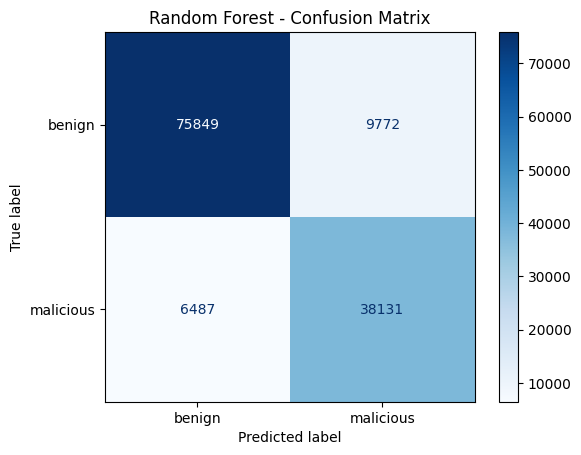

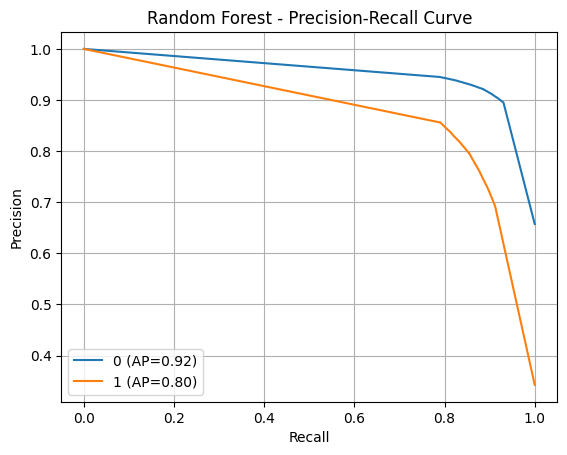


=== Evaluation: XGBoost ===

Classification Report:
              precision    recall  f1-score   support

      benign       0.79      0.59      0.68     85621
   malicious       0.47      0.70      0.56     44618

    accuracy                           0.63    130239
   macro avg       0.63      0.65      0.62    130239
weighted avg       0.68      0.63      0.64    130239



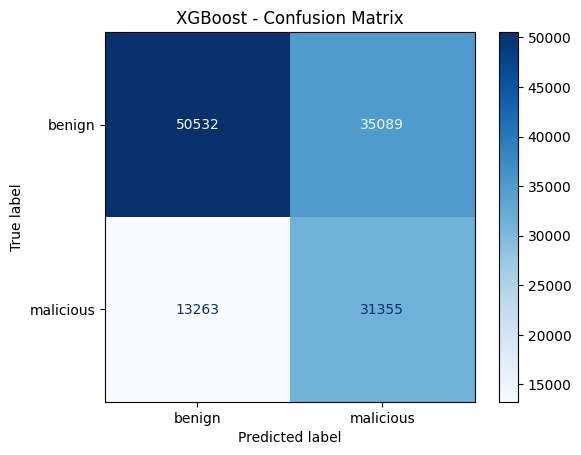

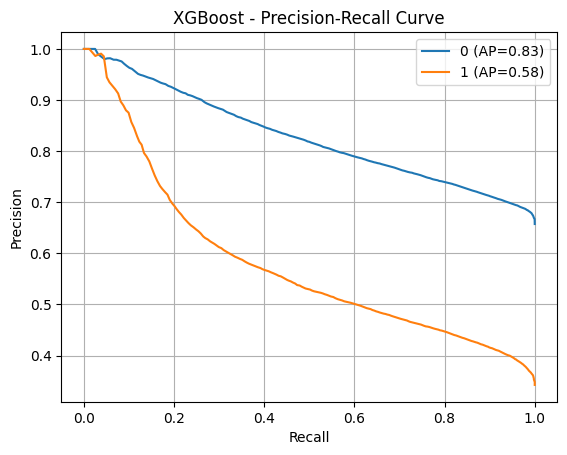


=== Evaluation: K-Nearest Neighbors ===

Classification Report:
              precision    recall  f1-score   support

      benign       0.92      0.87      0.89     85621
   malicious       0.77      0.86      0.81     44618

    accuracy                           0.86    130239
   macro avg       0.85      0.86      0.85    130239
weighted avg       0.87      0.86      0.87    130239



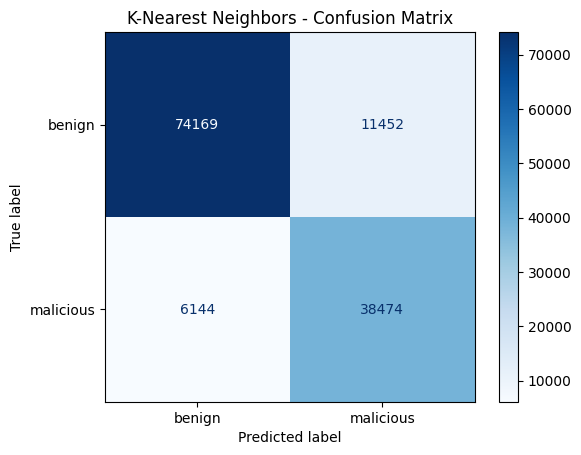

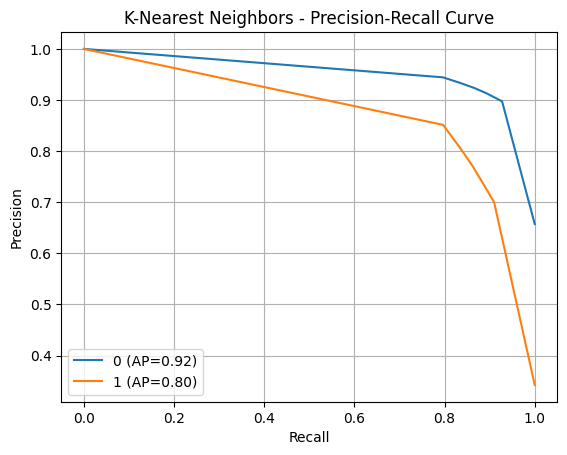


=== Evaluation: Neural Network ===

Classification Report:
              precision    recall  f1-score   support

      benign       0.75      0.43      0.55     85621
   malicious       0.40      0.73      0.52     44618

    accuracy                           0.53    130239
   macro avg       0.58      0.58      0.53    130239
weighted avg       0.63      0.53      0.54    130239



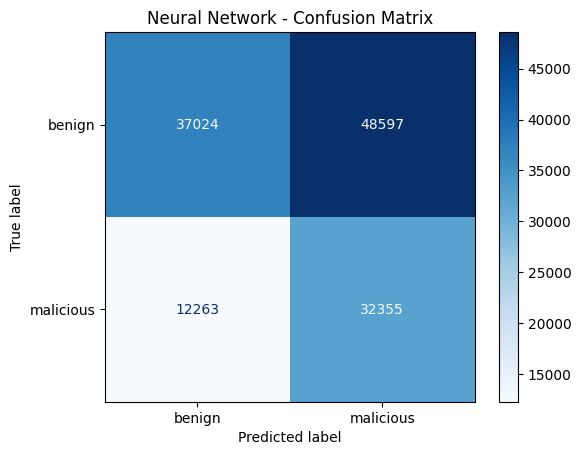

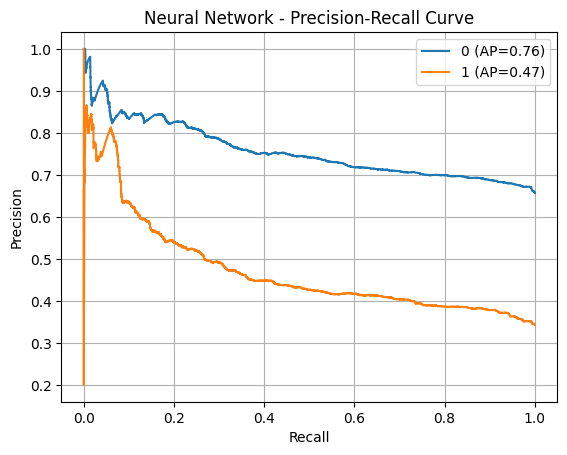


=== Evaluation: Naive Bayes ===

Classification Report:
              precision    recall  f1-score   support

      benign       0.67      0.49      0.57     85621
   malicious       0.36      0.53      0.43     44618

    accuracy                           0.51    130239
   macro avg       0.51      0.51      0.50    130239
weighted avg       0.56      0.51      0.52    130239



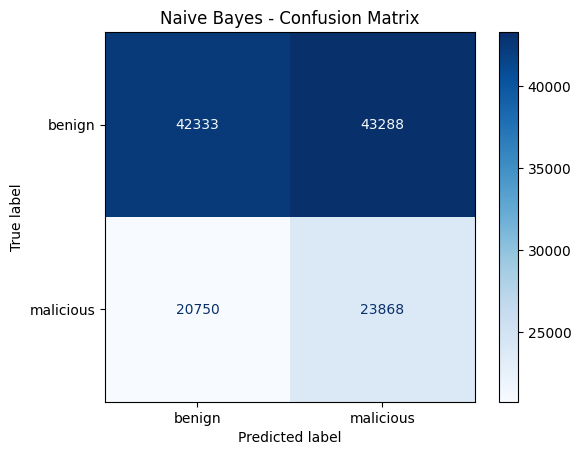

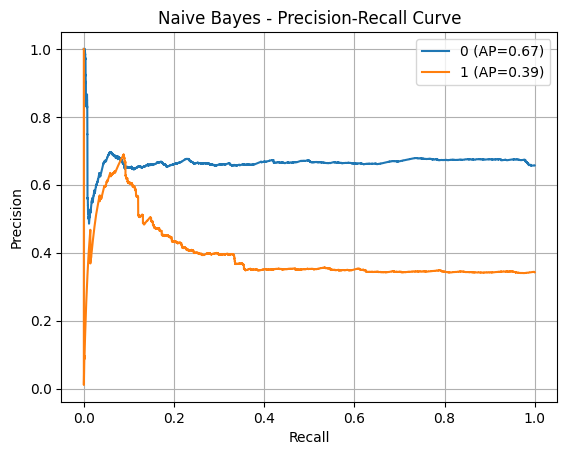

In [ ]:
#Model Evaluation Section

from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score #Import functions for generating detailed classification metrics

def evaluate_model(name, model, X_test_bal, y_test_bal):
    print(f"\n=== Evaluation: {name} ===")

    # Predictions
    y_pred = model.predict(X_test)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['benign', 'malicious']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'malicious'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

    # Precision-Recall Curve
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("Model does not support probability estimates.")
        return

    if y_scores.ndim > 1 and y_scores.shape[1] > 1:
        for i, class_label in enumerate(model.classes_):
            precision, recall, _ = precision_recall_curve(y_test == class_label, y_scores[:, i])
            ap = average_precision_score(y_test_bal == class_label, y_scores[:, i])
            plt.plot(recall, precision, label=f"{class_label} (AP={ap:.2f})")
    else:
        precision, recall, _ = precision_recall_curve(y_test, y_scores)
        ap = average_precision_score(y_test, y_scores)
        plt.plot(recall, precision, label=f"AP={ap:.2f}")

    plt.title(f"{name} - Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.show()

# Evaluate each model individually
evaluate_model("Random Forest", rf, X_test, y_test)
evaluate_model("XGBoost", xgb, X_test, y_test)
evaluate_model("K-Nearest Neighbors", knn, X_test, y_test)
evaluate_model("Neural Network", mlp, X_test, y_test)
evaluate_model("Naive Bayes", nb, X_test, y_test)


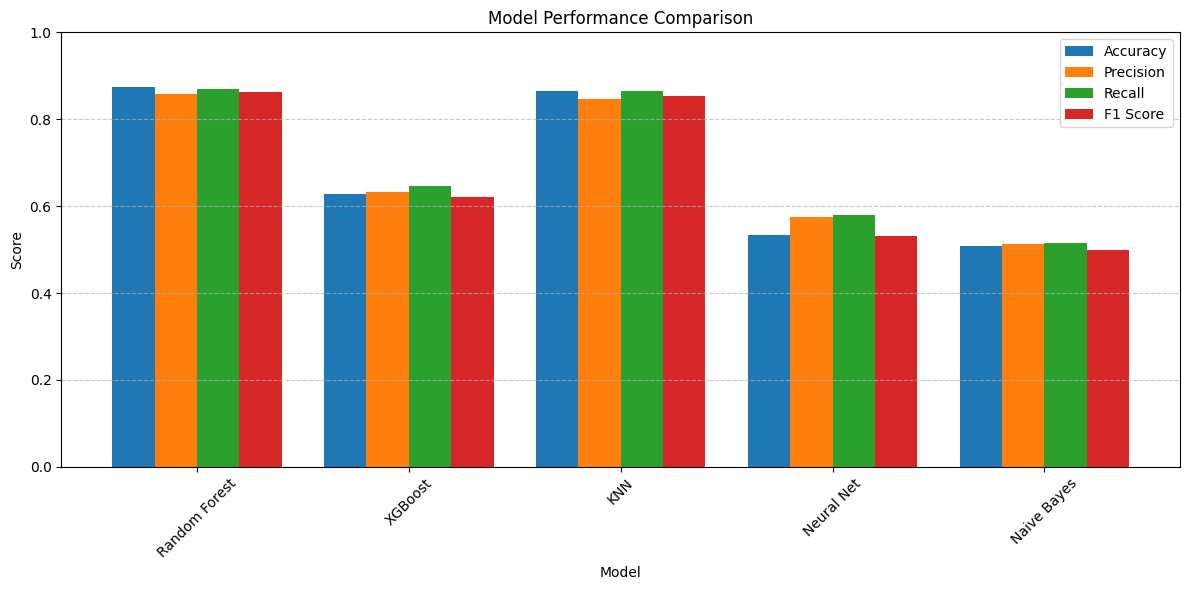


Best Model Per Metric:
Accuracy     Random Forest
Precision    Random Forest
Recall       Random Forest
F1 Score     Random Forest
dtype: object

Best Scores Per Metric:
Accuracy     Random Forest
Precision    Random Forest
Recall       Random Forest
F1 Score     Random Forest
dtype: object

Best Overall Model with The Highest Average Score: Random Forest


In [ ]:
# === MODEL COMPARISON AND FINAL EVALUATION ===

# Dictionary to store evaluation metrics
metrics_summary = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

# Evaluate and store metrics for each model
for name, model in models.items():
    y_pred = model.predict(X_test)

    metrics_summary["Model"].append(name)
    metrics_summary["Accuracy"].append(accuracy_score(y_test, y_pred))
    metrics_summary["Precision"].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    metrics_summary["Recall"].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    metrics_summary["F1 Score"].append(f1_score(y_test, y_pred, average='macro', zero_division=0))

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_summary)
metrics_df.set_index("Model", inplace=True)

# Calculate average of metrics
metrics_df["Average"] = metrics_df[["Accuracy", "Precision", "Recall", "F1 Score"]].mean(axis=1)

# === PLOT GROUPED BAR CHART ===
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.2
index = range(len(metrics_df.index))

plt.bar([i - 1.5*bar_width for i in index], metrics_df["Accuracy"], width=bar_width, label='Accuracy')
plt.bar([i - 0.5*bar_width for i in index], metrics_df["Precision"], width=bar_width, label='Precision')
plt.bar([i + 0.5*bar_width for i in index], metrics_df["Recall"], width=bar_width, label='Recall')
plt.bar([i + 1.5*bar_width for i in index], metrics_df["F1 Score"], width=bar_width, label='F1 Score')

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(index, metrics_df.index, rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# === FIND BEST PERFORMERS ===
best_model_per_metric = metrics_df.drop(columns=["Average"]).idxmax()
best_model_scores = metrics_df.drop(columns=["Average"]).idxmax()
best_model_overall = metrics_df["Average"].idxmax()

print("\nBest Model Per Metric:")
print(best_model_per_metric)

print("\nBest Scores Per Metric:")
print(best_model_scores)

print(f"\nBest Overall Model with The Highest Average Score: {best_model_overall}")
